In [1]:
!git clone https://github.com/bytedance-seed/depth-anything-3
%cd depth-anything-3
!pip install timm einops huggingface_hub safetensors
!pip install -e . --no-deps --quiet

Cloning into 'depth-anything-3'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 359 (delta 0), reused 0 (delta 0), pack-reused 357 (from 2)
Receiving objects: 100% (359/359), 22.66 MiB | 16.31 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/depth-anything-3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for depth-anything-3 (pyproject.toml) ... done


In [2]:
%cd src
!ls

/content/depth-anything-3/src
depth_anything_3


In [12]:
!pip install addict plyfile pycolmap trimesh evo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.2/162.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
depth-anything-3 0.0.0 requires e3nn, which is not installed.
depth-anything-3 0.0.0 requires open3d, which is not installed.
depth-anything-3 0.0.0 requires pillow-heif, which is not installed.
depth-anything-3 0.0.0 requires pre-commit, which is not installed.
depth-anything-3 0.0.0 requires xformers, which is not installed.
depth-anything-3 0.0.0 requires numpy<2, but you have numpy 2.0.2 which is incompatible.


In [13]:
%matplotlib inline
import sys, os, zipfile, urllib.request
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from depth_anything_3.api import DepthAnything3

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
H, W     = 96, 96
BATCH    = 16
N_EPOCHS = 12
LR       = 0.05
N_TRAIN  = 200
N_VAL    = 50
COLORS   = {'RGB':'#4C72B0', 'Depth':'#DD8452', 'RGB-D':'#55A868', 'Two-Stream':'#C44E52'}

print('device:', DEVICE)

device: cuda


## 1. Загрузка данных (Ants vs Bees)

In [14]:
DATA_URL = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
DATA_DIR = Path('hymenoptera_data')

if not DATA_DIR.exists():
    urllib.request.urlretrieve(DATA_URL, 'hymenoptera_data.zip')
    with zipfile.ZipFile('hymenoptera_data.zip') as zf:
        zf.extractall('.')

def read_images(folder: Path, limit: int) -> list:
    imgs = []
    for p in sorted(folder.glob('*.jpg'))[:limit]:
        img = Image.open(p).convert('RGB').resize((W, H), Image.BILINEAR)
        imgs.append(np.array(img, dtype=np.uint8))
    return imgs

tr_ants = read_images(DATA_DIR / 'train' / 'ants', N_TRAIN)
tr_bees = read_images(DATA_DIR / 'train' / 'bees', N_TRAIN)
va_ants = read_images(DATA_DIR / 'val'   / 'ants', N_VAL)
va_bees = read_images(DATA_DIR / 'val'   / 'bees', N_VAL)

train_imgs   = tr_ants + tr_bees
train_labels = [0]*len(tr_ants) + [1]*len(tr_bees)
val_imgs     = va_ants + va_bees
val_labels   = [0]*len(va_ants) + [1]*len(va_bees)

print(f'Train: {len(train_imgs)}, Val: {len(val_imgs)}')


Train: 243, Val: 100


## 2. Генерация карт глубины (Depth Anything 3)

In [15]:
def extract_depth(model, rgb_array: np.ndarray) -> np.ndarray:
    """
    Прогоняем кадр через DA3 → нормировка по 2/98 персентилям → ресайз до (H, W).
    Возвращает float32 массив [H, W] ∈ [0, 1].
    """
    with torch.no_grad():
        pred = model.inference(image=[rgb_array])
        d = pred.depth[0]
        if isinstance(d, torch.Tensor):
            d = d.cpu().numpy()
    p2, p98 = np.percentile(d, 2), np.percentile(d, 98)
    d_norm = np.clip((d - p2) / (p98 - p2 + 1e-8), 0.0, 1.0).astype(np.float32)
    return np.array(Image.fromarray(d_norm).resize((W, H), Image.BILINEAR))

da3 = DepthAnything3(model_name='da3-small').to(DEVICE).eval()

print('Train depths...')
train_depths = [extract_depth(da3, img) for img in train_imgs]
print('Val depths...')
val_depths   = [extract_depth(da3, img) for img in val_imgs]

del da3; torch.cuda.empty_cache()
print('Готово.')


[INFO ] using MLP layer as FFN
Train depths...
[INFO ] Processed Images Done taking 0.17823076248168945 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 3.0803539752960205 seconds
[INFO ] Conversion to Prediction Done. Time: 0.004737138748168945 seconds
[INFO ] Processed Images Done taking 0.07443380355834961 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.5496723651885986 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0010890960693359375 seconds
[INFO ] Processed Images Done taking 0.03789949417114258 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.14787507057189941 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0012691020965576172 seconds
[INFO ] Processed Images Done taking 0.024379730224609375 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.12307190895080566 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001

## 3. Визуализация: что именно строит DA3

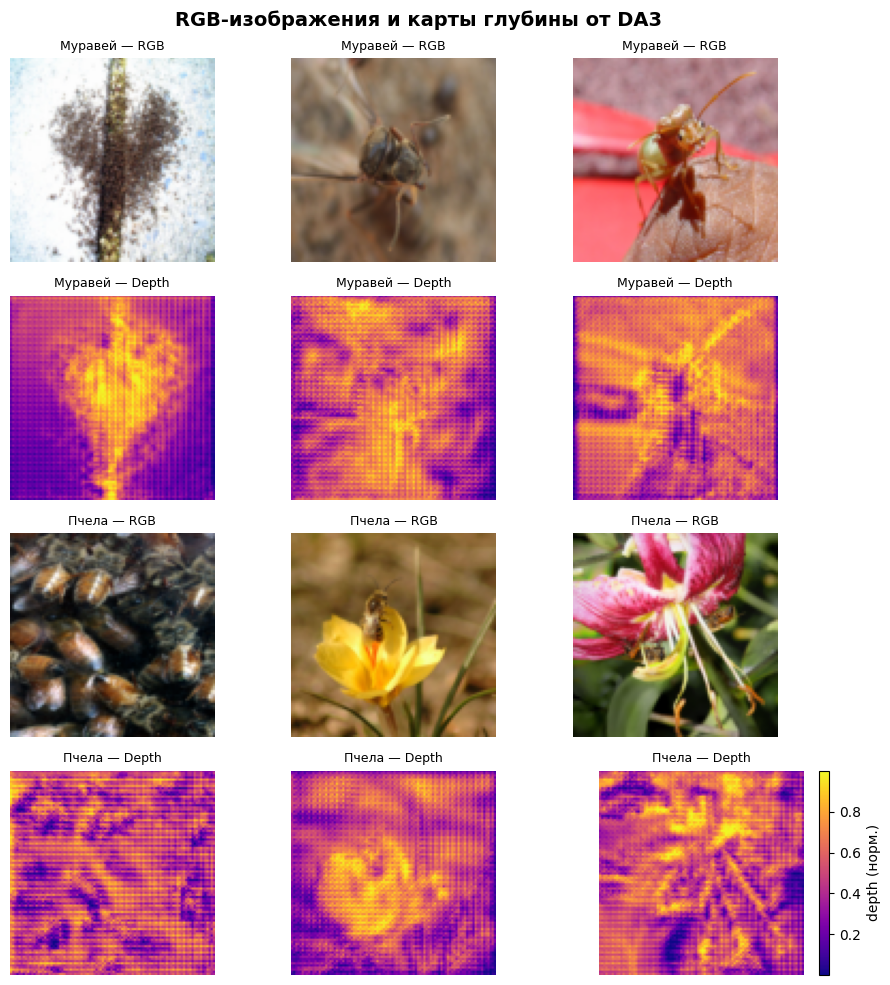

In [16]:
N_SHOW = 3
cls_names = {0: 'Муравей', 1: 'Пчела'}

fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW * 3.2, 10))
fig.suptitle('RGB-изображения и карты глубины от DA3', fontsize=14, fontweight='bold')

for cls_idx, cls_name in cls_names.items():
    idxs = [i for i, l in enumerate(val_labels) if l == cls_idx][:N_SHOW]
    row_rgb   = cls_idx * 2
    row_depth = cls_idx * 2 + 1
    for k, idx in enumerate(idxs):
        axes[row_rgb,   k].imshow(val_imgs[idx])
        axes[row_rgb,   k].set_title(f'{cls_name} — RGB', fontsize=9)
        axes[row_rgb,   k].axis('off')
        im = axes[row_depth, k].imshow(val_depths[idx], cmap='plasma')
        axes[row_depth, k].set_title(f'{cls_name} — Depth', fontsize=9)
        axes[row_depth, k].axis('off')

plt.colorbar(im, ax=axes[row_depth, -1], fraction=0.046, label='depth (норм.)')
plt.tight_layout()
plt.show()

## 4. Dataset / DataLoader

In [17]:
RGB_MEAN = [0.485, 0.456, 0.406]
RGB_STD  = [0.229, 0.224, 0.225]

class HymenopteraDataset(Dataset):
    def __init__(self, rgb_list, depth_list, labels, augment=False):
        self.rgb, self.depth, self.labels = rgb_list, depth_list, labels
        self.augment  = augment
        self.to_tensor = T.ToTensor()
        self.norm_rgb  = T.Normalize(mean=RGB_MEAN, std=RGB_STD)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        rgb_t = self.norm_rgb(self.to_tensor(self.rgb[idx]))
        dep_t = torch.from_numpy(self.depth[idx]).unsqueeze(0) * 2.0 - 1.0
        if self.augment and torch.rand(1) > 0.5:
            rgb_t = TF.hflip(rgb_t)
            dep_t = TF.hflip(dep_t)
        return rgb_t, dep_t, torch.tensor(self.labels[idx], dtype=torch.long)

train_loader = DataLoader(
    HymenopteraDataset(train_imgs, train_depths, train_labels, augment=True),
    batch_size=BATCH, shuffle=True, drop_last=True)
val_loader = DataLoader(
    HymenopteraDataset(val_imgs, val_depths, val_labels, augment=False),
    batch_size=BATCH, shuffle=False)

print(f'train batches: {len(train_loader)}, val batches: {len(val_loader)}')


train batches: 15, val batches: 7


## 5. Архитектуры

Используем **два** варианта:

- **InsectNet** — единый энкодер, принимает на вход конкатенированные каналы (RGB / Depth / RGB-D).
- **TwoStreamNet** — два независимых энкодера (RGB-бранч и Depth-бранч), признаки сливаются
  перед классификатором. Это *позднее слияние* в отличие от раннего в RGB-D.

In [18]:
class ConvBNAct(nn.Module):
    """Conv2d → BatchNorm → ELU"""
    def __init__(self, in_ch, out_ch, k=3, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride=stride, padding=k//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(inplace=True),
        )
    def forward(self, x): return self.block(x)


def make_backbone(in_ch, channels=(32, 64, 128)):
    c1, c2, c3 = channels
    return nn.Sequential(
        ConvBNAct(in_ch, c1, stride=2),
        ConvBNAct(c1,   c1),
        ConvBNAct(c1,   c2, stride=2),
        ConvBNAct(c2,   c2),
        ConvBNAct(c2,   c3, stride=2),
        ConvBNAct(c3,   c3),
        nn.AdaptiveAvgPool2d(1),
    )


class InsectNet(nn.Module):
    """Один энкодер. in_channels: 3 / 1 / 4."""
    def __init__(self, in_channels, n_classes=2):
        super().__init__()
        self.backbone = make_backbone(in_channels)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.backbone(x))


class TwoStreamNet(nn.Module):
    """
    Позднее слияние: RGB-бранч (3 ch) и Depth-бранч (1 ch) обучаются независимо,
    их признаки (по 64-d каждый) конкатенируются перед финальным линейным слоем.
    """
    def __init__(self, n_classes=2):
        super().__init__()
        self.rgb_enc = make_backbone(3,  channels=(32, 64, 64))
        self.dep_enc = make_backbone(1,  channels=(16, 32, 64))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(64 + 64, n_classes),
        )
    def forward(self, rgb, dep):
        f_rgb = self.rgb_enc(rgb)
        f_dep = self.dep_enc(dep)
        return self.head(torch.cat([f_rgb, f_dep], dim=1))


_rgb = torch.zeros(2, 3, H, W)
_dep = torch.zeros(2, 1, H, W)
assert InsectNet(3)(_rgb).shape == (2, 2)
assert InsectNet(1)(_dep).shape == (2, 2)
assert InsectNet(4)(torch.zeros(2, 4, H, W)).shape == (2, 2)
assert TwoStreamNet()(_rgb, _dep).shape == (2, 2)
print('Архитектуры OK')

Архитектуры OK


## 6. Цикл обучения

In [19]:
def get_x(rgb, dep, mode):
    if   mode == 'rgb':   return rgb
    elif mode == 'depth': return dep
    elif mode == 'rgbd':  return torch.cat([rgb, dep], dim=1)
    raise ValueError(mode)


def run_epoch(model, loader, mode, optimizer, criterion, train):
    model.train(train)
    total_loss, all_preds, all_true = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for rgb, dep, y in loader:
            rgb, dep, y = rgb.to(DEVICE), dep.to(DEVICE), y.to(DEVICE)

            if mode == 'twostream':
                logits = model(rgb, dep)
            else:
                logits = model(get_x(rgb, dep, mode))

            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            total_loss += loss.item() * y.size(0)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_true.extend(y.cpu().tolist())

    n = len(all_true)
    return (
        total_loss / n,
        accuracy_score(all_true, all_preds),
        f1_score(all_true, all_preds, average='macro', zero_division=0),
        all_preds, all_true,
    )


def train_model(model_fn, mode, label):
    model     = model_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    history = {'train_loss': [], 'val_acc': []}
    final_preds = final_true = None

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, *_           = run_epoch(model, train_loader, mode, optimizer, criterion, train=True)
        _, va_acc, va_f1, va_preds, va_true = run_epoch(model, val_loader, mode, None, criterion, train=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_acc'].append(va_acc)
        final_preds, final_true = va_preds, va_true

        if epoch % 3 == 0 or epoch == N_EPOCHS:
            print(f'  [{label}] {epoch:02d}/{N_EPOCHS}  '
                  f'loss={tr_loss:.3f}  val_acc={va_acc*100:.1f}%  f1={va_f1:.3f}')

    return history, va_acc, va_f1, final_preds, final_true

## 7. Эксперименты

Сравниваем четыре режима:
| Режим | Вход | Архитектура |
|---|---|---|
| **RGB** | 3 канала | InsectNet |
| **Depth** | 1 канал (DA3) | InsectNet |
| **RGB-D** | 4 канала (раннее слияние) | InsectNet |
| **Two-Stream** | RGB + Depth раздельно (позднее слияние) | TwoStreamNet |

In [20]:
results = {}

print('=== RGB ===')
results['RGB']        = train_model(lambda: InsectNet(3),    'rgb',       'RGB')

print('\n=== Depth ===')
results['Depth']      = train_model(lambda: InsectNet(1),    'depth',     'Depth')

print('\n=== RGB-D (раннее слияние) ===')
results['RGB-D']      = train_model(lambda: InsectNet(4),    'rgbd',      'RGB-D')

print('\n=== Two-Stream (позднее слияние) ===')
results['Two-Stream'] = train_model(lambda: TwoStreamNet(),  'twostream', 'Two-Stream')

=== RGB ===
  [RGB] 03/12  loss=1.106  val_acc=51.0%  f1=0.471
  [RGB] 06/12  loss=1.096  val_acc=46.0%  f1=0.458
  [RGB] 09/12  loss=0.723  val_acc=55.0%  f1=0.540
  [RGB] 12/12  loss=0.691  val_acc=58.0%  f1=0.580

=== Depth ===
  [Depth] 03/12  loss=0.722  val_acc=65.0%  f1=0.647
  [Depth] 06/12  loss=0.689  val_acc=64.0%  f1=0.640
  [Depth] 09/12  loss=0.650  val_acc=67.0%  f1=0.666
  [Depth] 12/12  loss=0.624  val_acc=64.0%  f1=0.640

=== RGB-D (раннее слияние) ===
  [RGB-D] 03/12  loss=0.842  val_acc=53.0%  f1=0.519
  [RGB-D] 06/12  loss=0.773  val_acc=60.0%  f1=0.599
  [RGB-D] 09/12  loss=0.761  val_acc=68.0%  f1=0.657
  [RGB-D] 12/12  loss=0.620  val_acc=69.0%  f1=0.683

=== Two-Stream (позднее слияние) ===
  [Two-Stream] 03/12  loss=0.806  val_acc=52.0%  f1=0.519
  [Two-Stream] 06/12  loss=0.677  val_acc=68.0%  f1=0.672
  [Two-Stream] 09/12  loss=0.678  val_acc=62.0%  f1=0.620
  [Two-Stream] 12/12  loss=0.620  val_acc=65.0%  f1=0.649


## 8. Кривые обучения

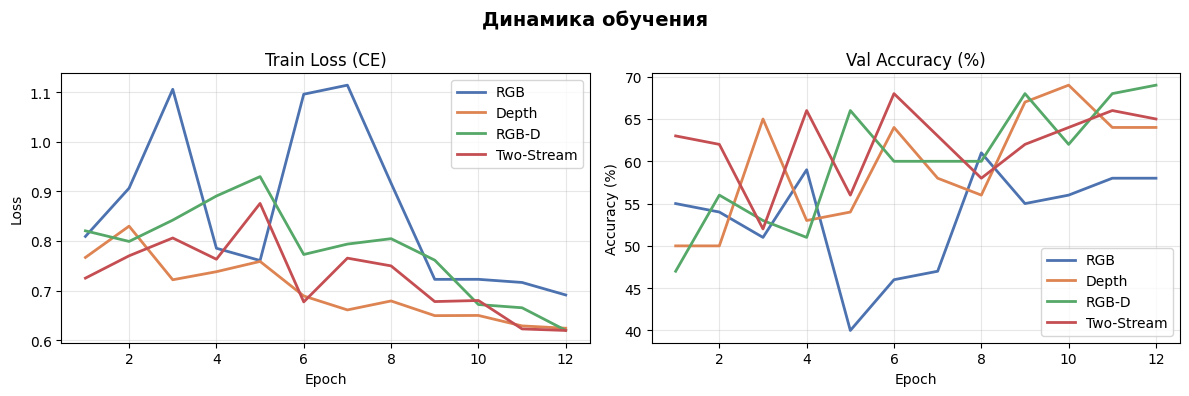

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, (hist, acc, f1, _, _) in results.items():
    ep = range(1, N_EPOCHS + 1)
    ax1.plot(ep, hist['train_loss'],         label=name, color=COLORS[name], lw=2)
    ax2.plot(ep, [v*100 for v in hist['val_acc']], label=name, color=COLORS[name], lw=2)

ax1.set_title('Train Loss (CE)');      ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.set_title('Val Accuracy (%)');     ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
for ax in (ax1, ax2):
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Динамика обучения', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Матрицы ошибок

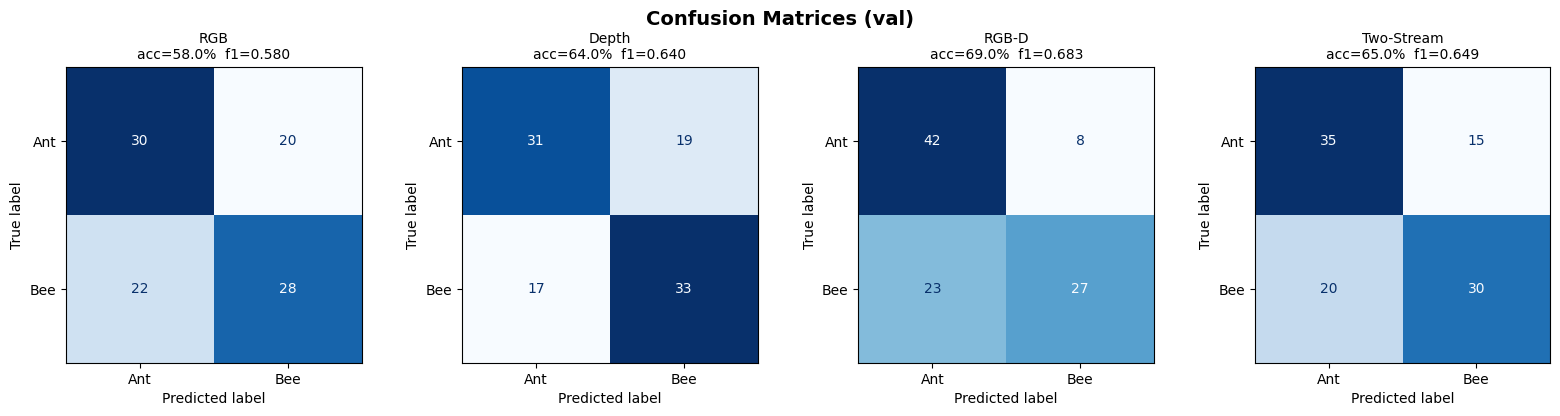

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, (_, acc, f1, preds, true)) in zip(axes, results.items()):
    cm   = confusion_matrix(true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ant', 'Bee'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nacc={acc*100:.1f}%  f1={f1:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices (val)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Итоговое сравнение

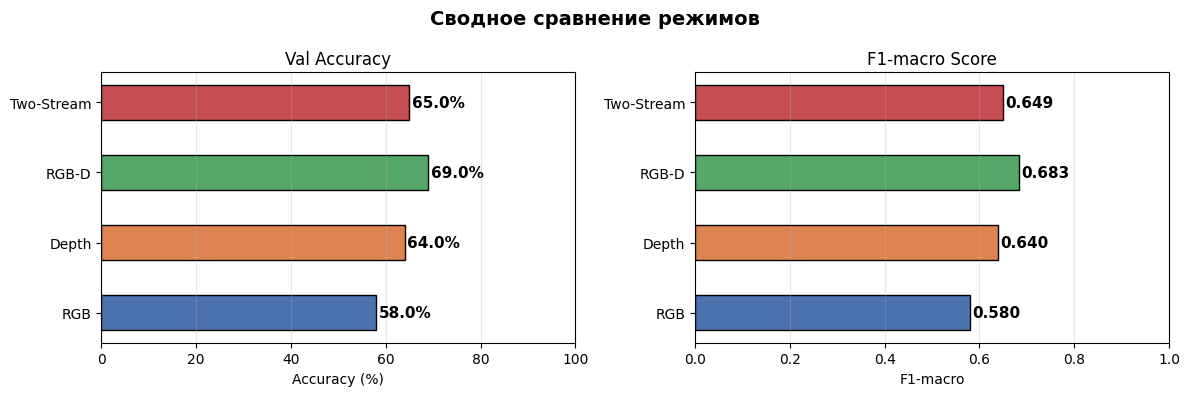


Режим             Accuracy   F1-macro
-------------------------------------
RGB                  58.0%      0.580
Depth                64.0%      0.640
RGB-D                69.0%      0.683
Two-Stream           65.0%      0.649


In [23]:
names = list(results.keys())
accs  = [results[n][1] * 100 for n in names]
f1s   = [results[n][2]       for n in names]
bar_colors = [COLORS[n] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars = ax1.barh(names, accs, color=bar_colors, edgecolor='black', height=0.5)
for bar, v in zip(bars, accs):
    ax1.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
ax1.set_xlim(0, 100); ax1.set_xlabel('Accuracy (%)'); ax1.set_title('Val Accuracy')
ax1.grid(axis='x', alpha=0.3)

bars = ax2.barh(names, f1s, color=bar_colors, edgecolor='black', height=0.5)
for bar, v in zip(bars, f1s):
    ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 1); ax2.set_xlabel('F1-macro'); ax2.set_title('F1-macro Score')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Сводное сравнение режимов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n{:<15} {:>10} {:>10}'.format('Режим', 'Accuracy', 'F1-macro'))
print('-' * 37)
for name, (_, acc, f1, _, _) in results.items():
    print('{:<15} {:>9.1f}% {:>10.3f}'.format(name, acc*100, f1))


## 11. Выводы

**Depth Anything 3** позволяет получить карту глубины из обычного RGB-снимка без специального
оборудования — по сути, это бесплатный «глубинный сенсор» для любого датасета.

Эксперимент на задаче классификации насекомых (Ants vs Bees, 243 тренировочных / 100 валидационных)
дал следующие результаты:

| Режим | Val Accuracy | F1-macro |
|---|---|---|
| **RGB-D** | **69.0%** | **0.683** |
| Two-Stream | 65.0% | 0.649 |
| Depth-only | 64.0% | 0.640 |
| RGB | 58.0% | 0.580 |

- **RGB (58.0%, F1=0.580)** — базовый уровень и наиболее слабый режим: модель опирается
  только на цвет и текстуру, геометрической информации нет.
- **Depth-only (64.0%, F1=0.640)** — заметный прирост над RGB: карта глубины от DA3
  несёт классово значимую информацию (форма тела, контраст насекомого с фоном),
  хотя без цвета различимость ограничена.
- **RGB-D, раннее слияние (69.0%, F1=0.683)** — лучший результат. Конкатенация
  глубины как 4-го канала дала сети явный прирост: геометрические признаки
  дополняют цвет и помогают «отделить» насекомое от фона.
- **Two-Stream, позднее слияние (65.0%, F1=0.649)** — второе место.
  Независимые энкодеры специализируются на своих модальностях, однако
  на столь малом датасете (243 примера) дополнительные параметры двойного
  энкодера не дают преимущества перед простым ранним слиянием.

**Общий вывод:** DA3 как вспомогательный инструмент повышает качество классификации
за счёт геометрической информации, недоступной без RGB-D камеры. В данном эксперименте
наилучшим оказалось раннее слияние (RGB-D): простой четырёхканальный вход оказался
эффективнее сложного двухпоточного энкодера на ограниченных данных.
